# ORIE 5260: Futures Data Cleaning, Monthly Return Reconstruction, and Exploratory Analysis

Run all cells in order. Outputs are saved under `output/`; source files remain unchanged.

**Dependencies:** Python 3.10+, pandas, numpy, matplotlib, openpyxl, and IPython.
If needed, run `python -m pip install pandas numpy matplotlib openpyxl ipykernel` in a terminal.
Supplementary dependencies in `.analysis_packages` are loaded automatically when that directory exists.

**Return definition and limitations:** Returns are month-end changes in the supplied Close series.
They are not investment returns incorporating margin financing, collateral interest, and transaction costs.
The files do not document continuous-contract construction, price adjustments, or roll methodology;
these require clarification from the course data provider. Currency-label corrections do not perform currency conversion.
Outliers are flagged but not removed or winsorized by default; results remain preliminary pending review.

**Output folders:** `quality/` for quality checks; `cleaned/` for standardized data;
`returns/` for returns and reconciliation; `statistics/` for descriptive statistics and autocorrelation;
`figures/` for PNG/SVG charts; `report.md` for the results report; `manifest.csv` for the file inventory.

## 1. Environment, Paths, and Configurable Parameters
Purpose: locate the input directory, import dependencies, create output folders, and configure outlier thresholds,
the instrument switch date, and autocorrelation lags.
Returns are stored as decimals: 0.05 means 5%. Rerunning cells updates outputs with the same filenames.

In [1]:
# Purpose: Initialize the environment and analysis parameters.
from pathlib import Path
import sys, os, json, hashlib, platform
ROOT = Path.cwd().resolve()
ROOT = next((p for p in [ROOT, *ROOT.parents] if (p / 'data' / 'FuturesUnderlyingData').is_dir()), ROOT)
DATA = ROOT / 'data'
if not (DATA / 'FuturesUnderlyingData').exists():
    raise FileNotFoundError('Set the notebook working directory to the project folder containing data/FuturesUnderlyingData.')
if (ROOT / '.analysis_packages').exists():
    sys.path.insert(0, str(ROOT / '.analysis_packages'))
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.matplotlib_cache'))
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Image
OUT = ROOT / 'output'
DIR = {name: OUT / name for name in ['quality', 'cleaned', 'returns', 'statistics', 'figures']}
for path in DIR.values():
    path.mkdir(parents=True, exist_ok=True)
PARAMS = dict(daily_abs_threshold=0.15, monthly_abs_threshold=0.30,
              robust_z_threshold=8.0, reconciliation_tolerance=1e-6,
              rl_er_switch='2008-12', acf_lags=[1, 3, 6, 12], acf_max_lag=24)
(OUT / 'parameters.json').write_text(json.dumps(PARAMS, indent=2), encoding='utf-8')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 180, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
def save_csv(frame, folder, name, index=True):
    frame.to_csv(DIR[folder] / name, index=index, encoding='utf-8-sig')
def save_figure(fig, name, preview=False):
    fig.tight_layout()
    for ext in ['png', 'svg']:
        fig.savefig(DIR['figures'] / f'{name}.{ext}', bbox_inches='tight')
    plt.close(fig)
    if preview:
        display(Image(filename=str(DIR['figures'] / f'{name}.png')))
print('Working directory:', ROOT)
print('Output directory:', OUT)

Working directory: C:\Users\miaoy\Desktop\ORIE 5260
Output directory: C:\Users\miaoy\Desktop\ORIE 5260\output


## 2. Load Raw Data and the Asset Map
Purpose: read all daily files and the reference monthly return table, record source-file checksums,
and align observations by calendar month before reconciliation.
Preserve original currency labels alongside standardized labels. The explicit corrections
`BPN -> GBP`, `HDK -> HKD`, and `CND -> CAD` change labels only; they do not convert prices or returns.

In [2]:
# Purpose: Load inputs, check required fields, and preserve original mapping labels.
mapping = pd.read_csv(DATA / 'AssetMapCsv.csv')
assert not mapping.ID.duplicated().any(), 'Duplicate IDs in the asset map require manual review.'
mapping['Ccy_original'] = mapping.Ccy
mapping['Ccy'] = mapping.Ccy.replace({'BPN': 'GBP', 'HDK': 'HKD', 'CND': 'CAD'})
save_csv(mapping, 'cleaned', 'asset_map_standardized.csv', index=False)
raw = {}
for file in sorted((DATA / 'FuturesUnderlyingData').glob('*.csv')):
    frame = pd.read_csv(file, index_col=0)
    frame.index = pd.to_datetime(frame.index, errors='raise')
    frame.index.name = 'Date'
    expected = ['Open', 'High', 'Low', 'Close', 'Volume', 'OpenInterest']
    if not set(expected).issubset(frame.columns):
        raise ValueError(f'{file.name} is missing required fields')
    raw[file.stem] = frame[expected].apply(pd.to_numeric, errors='raise')
reference = pd.read_csv(DATA / 'MonthlyReturns.csv', index_col=0)
reference_dates = pd.to_datetime(reference.index)
reference.index = reference_dates.to_period('M')
reference.index.name = 'Month'
assert reference.index.is_unique, 'Duplicate months in the reference return table prevent direct reconciliation.'
reference = reference.sort_index()
sources = list((DATA / 'FuturesUnderlyingData').glob('*.csv')) + [
    DATA / n for n in ['AssetMapCsv.csv', 'MonthlyReturns.csv', 'Lecture3_livedata.xlsx']]
source_inventory = pd.DataFrame([{'file': str(p.relative_to(ROOT)), 'bytes': p.stat().st_size,
    'sha256': hashlib.sha256(p.read_bytes()).hexdigest()} for p in sources])
save_csv(source_inventory, 'quality', 'source_inventory.csv', index=False)
mapping_issues = pd.DataFrame([
    *[{'ID': k, 'issue': 'mapped_but_raw_file_missing'} for k in sorted(set(mapping.ID)-set(raw))],
    *[{'ID': k, 'issue': 'raw_but_not_mapped'} for k in sorted(set(raw)-set(mapping.ID))],
    *[{'ID': k, 'issue': 'raw_but_not_reference_column'} for k in sorted(set(raw)-set(reference))]])
save_csv(mapping_issues, 'quality', 'mapping_issues.csv', index=False)
print(f'Raw instruments: {len(raw)}; asset-map rows: {len(mapping)}; reference monthly returns: {reference.shape}')
display(mapping_issues)

Raw instruments: 62; asset-map rows: 66; reference monthly returns: (552, 58)


,ID,issue
0,BC,mapped_but_raw_file_missing
1,BG,mapped_but_raw_file_missing
2,FF,mapped_but_raw_file_missing
3,ZH,mapped_but_raw_file_missing
4,EN,raw_but_not_reference_column
5,ER,raw_but_not_reference_column
6,ES,raw_but_not_reference_column
7,SC,raw_but_not_reference_column


## 3. Data Quality Checks and Outlier Flags
Purpose: check dates, duplicates, missing and nonfinite values, OHLC relationships, nonpositive prices,
and volume/open interest. Identical observations on the same date are deduplicated.
Conflicting observations on the same date stop execution rather than selecting a row arbitrarily.
Daily returns are screened using an absolute threshold and a median/MAD robust z-score.
These thresholds identify review candidates, not confirmed errors.
Calendar gaps longer than seven days are flagged for review; holidays are not automatically classified as missing data.

In [3]:
# Purpose: Build instrument summaries and quality logs; export standardized daily observations.
overview, events, clean, daily_flags = [], [], {}, []
for symbol, original in raw.items():
    frame = original.sort_index().copy()
    duplicate_count = int(frame.index.duplicated().sum())
    if duplicate_count:
        for date, group in frame[frame.index.duplicated(keep=False)].groupby(level=0):
            if len(group.drop_duplicates()) > 1:
                raise ValueError(f'{symbol} {date}: Conflicting observations on the same date require review.')
        frame = frame[~frame.index.duplicated(keep='first')]
    prices = frame[['Open', 'High', 'Low', 'Close']]
    tests = {
        'missing_field': frame.isna().any(axis=1),
        'nonfinite_field': pd.Series((~np.isfinite(frame.to_numpy())).any(axis=1), index=frame.index),
        'nonpositive_price': (prices <= 0).any(axis=1),
        'invalid_ohlc': (frame.High < prices[['Open','Close','Low']].max(axis=1)) |
                        (frame.Low > prices[['Open','Close','High']].min(axis=1)),
        'negative_volume_or_oi': (frame[['Volume','OpenInterest']] < 0).any(axis=1),
        'calendar_gap_gt_7_days': frame.index.to_series().diff().dt.days > 7}
    for kind, mask in tests.items():
        for date, row in frame.loc[mask].iterrows():
            events.append({'ID': symbol, 'Date': date, 'issue': kind, **row.to_dict()})
    returns = frame.Close.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan)
    median = returns.median()
    mad = (returns - median).abs().median()
    z = (returns - median) / (1.4826 * mad) if mad > 0 else returns * np.nan
    mask = (returns.abs() > PARAMS['daily_abs_threshold']) | (z.abs() > PARAMS['robust_z_threshold'])
    for date in frame.index[mask]:
        daily_flags.append({'ID': symbol, 'Date': date, 'daily_return': returns.loc[date],
                            'robust_z': z.loc[date], 'Close': frame.loc[date, 'Close']})
    overview.append({'ID': symbol, 'rows': len(frame), 'start': frame.index.min(), 'end': frame.index.max(),
                     'duplicate_dates': duplicate_count, 'original_sorted': original.index.is_monotonic_increasing,
                     'missing_cells': int(frame.isna().sum().sum()),
                     'ohlc_issues': int(tests['invalid_ohlc'].sum()), 'flagged_daily_returns': int(mask.sum())})
    clean[symbol] = frame
overview = pd.DataFrame(overview).merge(mapping, on='ID', how='left')
quality_events = pd.DataFrame(events, columns=['ID','Date','issue','Open','High','Low','Close','Volume','OpenInterest'])
daily_flags = pd.DataFrame(daily_flags, columns=['ID','Date','daily_return','robust_z','Close'])
save_csv(overview, 'quality', 'instrument_overview.csv', False)
save_csv(quality_events, 'quality', 'quality_events.csv', False)
save_csv(daily_flags, 'quality', 'daily_return_outliers.csv', False)
save_csv(pd.concat(clean, names=['ID','Date']), 'cleaned', 'daily_prices_long.csv')
print('Quality events:', len(quality_events), '; flagged daily returns:', len(daily_flags))
display(quality_events.head(10))

Quality events: 9 ; flagged daily returns: 582


,ID,Date,issue,Open,High,Low,Close,Volume,OpenInterest
0,ER,2012-05-28,invalid_ohlc,823.770,829.350,822.160,820.450,83570.0,442335.0
1,SS,1992-01-02,calendar_gap_gt_7_days,87.837,87.886,87.837,87.886,1730.0,0.0
2,SS,1993-01-04,calendar_gap_gt_7_days,90.613,90.633,90.613,90.623,427.0,0.0
3,SS,1994-01-04,calendar_gap_gt_7_days,90.684,90.684,90.674,90.674,1734.0,0.0
4,SS,1995-01-03,calendar_gap_gt_7_days,90.548,90.558,90.548,90.558,345.0,0.0
5,SS,1996-01-02,calendar_gap_gt_7_days,92.141,92.141,92.141,92.141,76.0,0.0
6,SS,1997-01-02,calendar_gap_gt_7_days,91.964,91.964,91.954,91.964,530.0,0.0
7,SS,1998-01-05,calendar_gap_gt_7_days,91.794,91.814,91.794,91.814,1262.0,0.0
8,SS,1999-01-04,calendar_gap_gt_7_days,92.541,92.541,92.531,92.541,1318.0,0.0


## 4. Reconstruct Monthly Returns for Each Raw Instrument
Purpose: select the last nonmissing Close within each month and retain the actual observation date
and the number of available daily closing-price observations.
Reindex prices to a complete monthly calendar before computing adjacent-month price ratios.
Do not forward-fill prices or calculate a one-month return across a missing month.
An instrument that stops trading early in a month may produce an incomplete final month.
Record the number of calendar days from the selected observation to month-end; this gap alone does not establish an error.

For each instrument, compute `r[t] = P[t] / P[t-1] - 1`, where `P[t]` is that month's last nonmissing Close.
If either adjacent monthly price is missing, the return is missing. A missing price in February therefore
makes both February and March returns unavailable, even if January and March prices exist.
The first observed price month has no return without the preceding month's price.

In [4]:
# Purpose: Build month-end prices, monthly returns, and coverage records for 62 instruments.
calendar = pd.period_range(min(d.index.min() for d in clean.values()).to_period('M'),
                           max(d.index.max() for d in clean.values()).to_period('M'), freq='M')
calendar.name = 'Month'
monthly_prices = pd.DataFrame(index=calendar)
last_dates = pd.DataFrame(index=calendar)
monthly_counts = pd.DataFrame(index=calendar)
for symbol, frame in clean.items():
    valid = frame.Close.dropna()
    key = valid.index.to_period('M')
    monthly_prices[symbol] = valid.groupby(key).last().reindex(calendar)
    last_dates[symbol] = pd.Series(valid.index, index=key).groupby(level=0).last().reindex(calendar)
    monthly_counts[symbol] = valid.groupby(key).size().reindex(calendar, fill_value=0)
raw_monthly_returns = monthly_prices.pct_change(fill_method=None).replace([np.inf,-np.inf], np.nan)
coverage_rows = []
for symbol in monthly_prices:
    for month in calendar:
        date = last_dates.loc[month, symbol]
        coverage_rows.append({'ID':symbol, 'Month':month, 'last_price_date':date,
            'observations':monthly_counts.loc[month,symbol],
            'calendar_days_to_month_end':(month.end_time.normalize()-date).days if pd.notna(date) else np.nan})
save_csv(monthly_prices, 'returns', 'month_end_prices_62.csv')
save_csv(raw_monthly_returns, 'returns', 'monthly_returns_raw_62.csv')
save_csv(pd.DataFrame(coverage_rows), 'quality', 'monthly_price_coverage.csv', False)
display(raw_monthly_returns.tail())

,AN,AP,AX,BN,CA,CB,CC,CN,CT,DA,...,ZM,ZN,ZO,ZP,ZR,ZS,ZT,ZU,ZW,ZZ
Month,,,,,,,,,,,,,,,,,,,,,
2014-08,0.006515,0.008078,0.011149,-0.018705,0.031678,0.014668,0.007019,0.003385,0.058932,0.111218,...,0.005416,0.049707,0.043119,-0.027660,-0.023132,-0.053383,-0.037499,-0.014361,0.045009,-0.048946
2014-09,-0.061489,-0.058950,-0.002628,-0.021565,0.009670,-0.013470,0.022140,-0.029096,-0.078102,0.011537,...,-0.147694,-0.002140,-0.019733,-0.088527,0.006343,-0.108371,0.055269,-0.041302,-0.152175,0.086181
2014-10,0.008276,0.044482,-0.014071,-0.012677,-0.041131,0.011406,-0.121540,-0.005396,0.050160,0.009980,...,0.301453,-0.083786,0.002258,-0.050181,-0.048217,0.140052,0.015753,-0.109143,0.114599,-0.068766
2014-11,-0.030894,-0.032622,0.069914,-0.023030,0.038746,0.016464,-0.017352,-0.013541,-0.065121,-0.051948,...,-0.029636,0.031049,-0.089161,-0.019361,0.004084,-0.031683,0.016565,-0.178441,0.074119,0.017942
2014-12,-0.037996,0.016760,-0.019915,-0.002412,-0.024876,0.005669,0.023699,-0.014222,0.003119,-0.097975,...,-0.020056,-0.297469,-0.008988,-0.002642,-0.064193,-0.000385,-0.033537,-0.197605,0.019450,-0.079622


## 5. Instrument Selection, Reference Reconstruction, and Reconciliation
Purpose: produce two explicitly distinguished datasets.

* **58-column reference reconstruction:** retain the reference table's columns.
  Starting in December 2008, use ER's own monthly returns for RL.
  Calculate each raw instrument's returns first, then select the return source by month;
  do not splice price levels with potentially different scales.
* **57-column economic-instrument dataset:** remove YM from the reconstruction and retain ZD for Dow Jones
  to avoid counting that index exposure twice. Retain SP from SP/ES/SC and ND from ND/EN.
  Join RL/ER using the switch above. Do not automatically merge MW and ZW merely because both reference wheat,
  or treat other similar instrument names as identical contracts.

These are transparent, editable analysis choices. In particular, the Dow Jones exclusion and other candidate
relationships should be checked against course requirements. Excluding an alternative instrument does not
automatically use it to fill gaps in the retained instrument.

Reconciliation checks both numeric differences and missingness. Matching all jointly observed values
does not imply identical tables. Values reconstructed from raw prices where the reference is missing are retained
and labeled `reference_missing`; these are calculated observations, not statistical imputations.

### Required reconstruction versus optional deduplication

The primary deliverable follows the supplied reference table's 58 instrument columns.
The screenshot requests return reconstruction, duplicate/merge handling, and exploratory analysis;
it does not mandate 57 instruments. The 57-column dataset is an additional modeling choice,
not the uniquely correct universe or a replacement for the reference-compatible deliverable.

| Candidate group | Reference-compatible rule | Reduction from 62 raw columns |
| --- | --- | ---: |
| SP / ES / SC | Retain SP | 2 |
| ND / EN | Retain ND | 1 |
| RL / ER | Retain RL through 2008-11; use ER monthly returns from 2008-12 under the RL column | 1 |
| ZD / YM | Retain BOTH in the primary 58-column deliverable | 0 |

Thus, 62 - 2 - 1 - 1 = 58. Excluding YM while retaining ZD produces the optional
57-column economic-exposure dataset. This can avoid double-weighting Dow Jones in an
analysis portfolio, but should be justified explicitly and is not required by the screenshot.
Retain separate contracts when investigating differences between contract variants.
The existing instrument/class statistics and charts in Sections 6-8 use the optional
57-column dataset; they are supplementary, not evidence that the primary CSV has 57 columns.

### Primary cleaned CSV exports

- `MonthlyReturns.csv` in the project root is the primary reconstructed 58-column deliverable.
- `data/MonthlyReturns_cleaned.csv` is a byte-identical copy.
- `data/MonthlyReturns.csv` remains the untouched original reference input.

The primary exports retain the reference column order, row order, date labels, and unnamed
first date column for compatibility. Dates are aligned by calendar month internally.
All reference-observed values are reconstructed from raw prices and checked within 1e-6;
32 reference-missing values can be calculated from available raw month-end prices and are retained.
No interpolation, zero filling, forward filling, winsorization, or automatic outlier deletion is applied.
Pre-history missing values remain blank, and instrument start dates are not artificially equalized.
The 75-month common sample is a separate comparison dataset, not the primary export.


In [5]:
# Purpose: Apply explicit selection rules and record monthly return provenance and reconciliation.
rules = pd.DataFrame([
    ['SP','SP / ES / SC','SP','all','retain SP; exclude mini/alternative series'],
    ['ND','ND / EN','ND','all','retain ND'],
    ['RL','RL / ER','RL then ER',PARAMS['rl_er_switch'],'select ER monthly returns from switch month'],
    ['ZD','ZD / YM','ZD','all','exclude YM only from unique-economic analysis']],
    columns=['canonical','candidates','selected','switch_month','rule'])
save_csv(rules, 'cleaned', 'merge_rules.csv', False)
recreated = raw_monthly_returns.reindex(columns=reference.columns).copy()
provenance = pd.DataFrame({c: c for c in recreated}, index=calendar)
switch = pd.Period(PARAMS['rl_er_switch'], freq='M')
recreated.loc[calendar >= switch, 'RL'] = raw_monthly_returns.loc[calendar >= switch, 'ER']
provenance.loc[calendar >= switch, 'RL'] = 'ER'
provenance = provenance.where(recreated.notna())
unique_returns = recreated.drop(columns=['YM']).copy()
save_csv(recreated, 'returns', 'monthly_returns_recreated_58.csv')

# Export the primary 58-column deliverable using the reference CSV layout.
# Keep the original input in data/MonthlyReturns.csv unchanged.
reference_layout = pd.read_csv(DATA / 'MonthlyReturns.csv', index_col=0)
export_months = pd.to_datetime(reference_layout.index).to_period('M')
primary_export = recreated.reindex(index=export_months, columns=reference_layout.columns).copy()
primary_export.index = reference_layout.index.copy()
primary_export.index.name = reference_layout.index.name
primary_path = ROOT / 'MonthlyReturns.csv'
cleaned_copy_path = DATA / 'MonthlyReturns_cleaned.csv'
primary_export.to_csv(primary_path, encoding='utf-8-sig')
cleaned_copy_path.write_bytes(primary_path.read_bytes())
assert primary_export.shape == reference_layout.shape
assert primary_export.columns.tolist() == reference_layout.columns.tolist()
assert primary_path.read_bytes() == cleaned_copy_path.read_bytes()

save_csv(unique_returns, 'returns', 'monthly_returns_unique_57.csv')
save_csv(provenance, 'returns', 'monthly_return_source.csv')
all_months = reference.index.union(recreated.index).sort_values()
audit_rows = []
for symbol in reference:
    given = reference[symbol].reindex(all_months)
    rebuilt = recreated[symbol].reindex(all_months)
    both = given.notna() & rebuilt.notna()
    difference = rebuilt - given
    status = pd.Series('both_missing', index=all_months)
    status.loc[both] = 'match'
    status.loc[both & (difference.abs() > PARAMS['reconciliation_tolerance'])] = 'value_mismatch'
    status.loc[given.isna() & rebuilt.notna()] = 'reference_missing'
    status.loc[given.notna() & rebuilt.isna()] = 'rebuilt_missing'
    audit_rows.append(pd.DataFrame({'ID':symbol, 'Month':all_months.astype(str),
        'reference':given.values, 'rebuilt':rebuilt.values, 'difference':difference.values, 'status':status.values}))
reconciliation = pd.concat(audit_rows, ignore_index=True)
differences = reconciliation[~reconciliation.status.isin(['match','both_missing'])]
save_csv(reconciliation, 'returns', 'reconciliation_all.csv', False)
save_csv(differences, 'returns', 'reconciliation_differences.csv', False)
save_csv(reconciliation.groupby(['ID','status']).size().unstack(fill_value=0), 'returns', 'reconciliation_summary.csv')
monthly_flags = []
for symbol in unique_returns:
    for month, value in unique_returns[symbol].items():
        if pd.notna(value) and abs(value) > PARAMS['monthly_abs_threshold']:
            monthly_flags.append({'ID':symbol,'Month':month,'monthly_return':value})
save_csv(pd.DataFrame(monthly_flags, columns=['ID','Month','monthly_return']), 'quality', 'monthly_return_outliers.csv', False)
display(reconciliation.status.value_counts().rename('cells').to_frame())
display(differences.head(12))

,cells
status,
match,20987
both_missing,10997
reference_missing,32


,ID,Month,reference,rebuilt,difference,status
1655,AX,2014-12,NaN,-0.019915,NaN,reference_missing
5858,DT,1997-03,NaN,-0.022985,NaN,reference_missing
5859,DT,1997-04,NaN,0.011931,NaN,reference_missing
6071,DT,2014-12,NaN,0.013038,NaN,reference_missing
8066,GS,1997-03,NaN,-0.025706,NaN,reference_missing
8067,GS,1997-04,NaN,0.014912,NaN,reference_missing
8724,HS,2006-01,NaN,0.066082,NaN,reference_missing
8725,HS,2006-02,NaN,0.001834,NaN,reference_missing
11378,LX,1997-03,NaN,0.001649,NaN,reference_missing
11379,LX,1997-04,NaN,0.032227,NaN,reference_missing


## 6. Descriptive Statistics and Asset-Class Portfolios
Purpose: calculate monthly means, sample standard deviations, observation counts, sample coverage,
extreme returns, and conventional annualized summaries for each economic instrument.
Annualized arithmetic mean = monthly mean x 12; annualized volatility = monthly standard deviation x sqrt(12).
These are conventional scalings, not evidence that returns are serially uncorrelated.

Within each asset class, assign equal weights to instruments with observed returns in that month and rebalance monthly.
Save actual weights and member counts. Missing instruments receive no weight for that month;
if all instruments in a class are missing, the class return is missing rather than zero.
No currency conversion is performed, so these are statistical portfolios of locally quoted returns,
not unified USD investment portfolios.

Individual statistics use available observations. Also report statistics for months in which all instruments
have observed returns, to distinguish sample-period effects from differences between instruments.

In [6]:
# Purpose: Compute instrument, asset-class, and common-sample statistics.
asset_class = mapping.set_index('ID').AssetClass.reindex(unique_returns.columns)
assert asset_class.notna().all(), 'Some instruments have no asset-class classification.'
def summarize(frame):
    rows = []
    for symbol in frame:
        s = frame[symbol].dropna()
        first, last = frame[symbol].first_valid_index(), frame[symbol].last_valid_index()
        gaps = int(frame.loc[first:last,symbol].isna().sum()) if len(s) else 0
        rows.append({'ID':symbol, 'n_months':len(s), 'start':str(first), 'end':str(last),
            'internal_missing_months':gaps, 'monthly_mean':s.mean(), 'monthly_std':s.std(ddof=1),
            'annualized_arithmetic_mean':12*s.mean(), 'annualized_volatility':np.sqrt(12)*s.std(ddof=1),
            'min_monthly_return':s.min(), 'max_monthly_return':s.max()})
    return pd.DataFrame(rows).set_index('ID')
instrument_stats = summarize(unique_returns).join(asset_class.rename('AssetClass'))
save_csv(instrument_stats, 'statistics', 'instrument_statistics.csv')
class_returns = pd.DataFrame(index=calendar)
class_counts = pd.DataFrame(index=calendar)
weight_frames = []
for category in sorted(asset_class.unique()):
    members = asset_class.index[asset_class == category]
    block = unique_returns[members]
    class_counts[category] = block.notna().sum(axis=1)
    weights = block.notna().astype(float).div(class_counts[category].replace(0,np.nan),axis=0)
    class_returns[category] = block.mean(axis=1, skipna=True)
    weights.columns.name = 'ID'
    long = weights.stack().dropna().rename('weight').reset_index()
    long['AssetClass'] = category
    weight_frames.append(long)
class_stats = summarize(class_returns)
common = unique_returns.dropna(how='any')
common_stats = summarize(common).join(asset_class.rename('AssetClass'))
common_class_returns = pd.DataFrame({c:common.loc[:,asset_class == c].mean(axis=1) for c in sorted(asset_class.unique())})
save_csv(class_returns, 'returns', 'asset_class_equal_weight_returns.csv')
save_csv(class_counts, 'statistics', 'asset_class_member_counts.csv')
save_csv(pd.concat(weight_frames, ignore_index=True), 'returns', 'asset_class_weights.csv', False)
save_csv(class_stats, 'statistics', 'asset_class_statistics.csv')
save_csv(common, 'returns', 'common_sample_returns.csv')
save_csv(common_stats, 'statistics', 'common_sample_instrument_statistics.csv')
save_csv(summarize(common_class_returns), 'statistics', 'common_sample_asset_class_statistics.csv')
print('Common observed months:',len(common))
display(class_stats)

Common observed months: 75


,n_months,start,end,internal_missing_months,monthly_mean,monthly_std,annualized_arithmetic_mean,annualized_volatility,min_monthly_return,max_monthly_return
ID,,,,,,,,,,
COMM,551,1969-02,2014-12,0,0.004336,0.041144,0.052031,0.142528,-0.167997,0.227427
EQ,392,1982-05,2014-12,0,0.005534,0.046221,0.066410,0.160116,-0.204079,0.132149
FI,443,1978-02,2014-12,0,0.002213,0.023859,0.026558,0.082649,-0.093536,0.135882
FX,478,1975-03,2014-12,0,0.000878,0.020450,0.010539,0.070842,-0.083106,0.068262


## 7. Cumulative Returns and Descriptive Charts
Purpose: save cumulative-return data and charts for individual instruments, asset classes, common samples,
member counts, and mean/volatility comparisons.
Cumulative return is the product of (1 + r) minus 1.
Each full-history series starts at its first observed return. Once an internal missing return occurs,
cumulative values remain unavailable thereafter; missing returns are neither treated as zero nor silently skipped.
Common-sample charts use the longest continuous interval with observations for all instruments.
Save every chart as PNG and SVG. Chart labels are in English for portability.

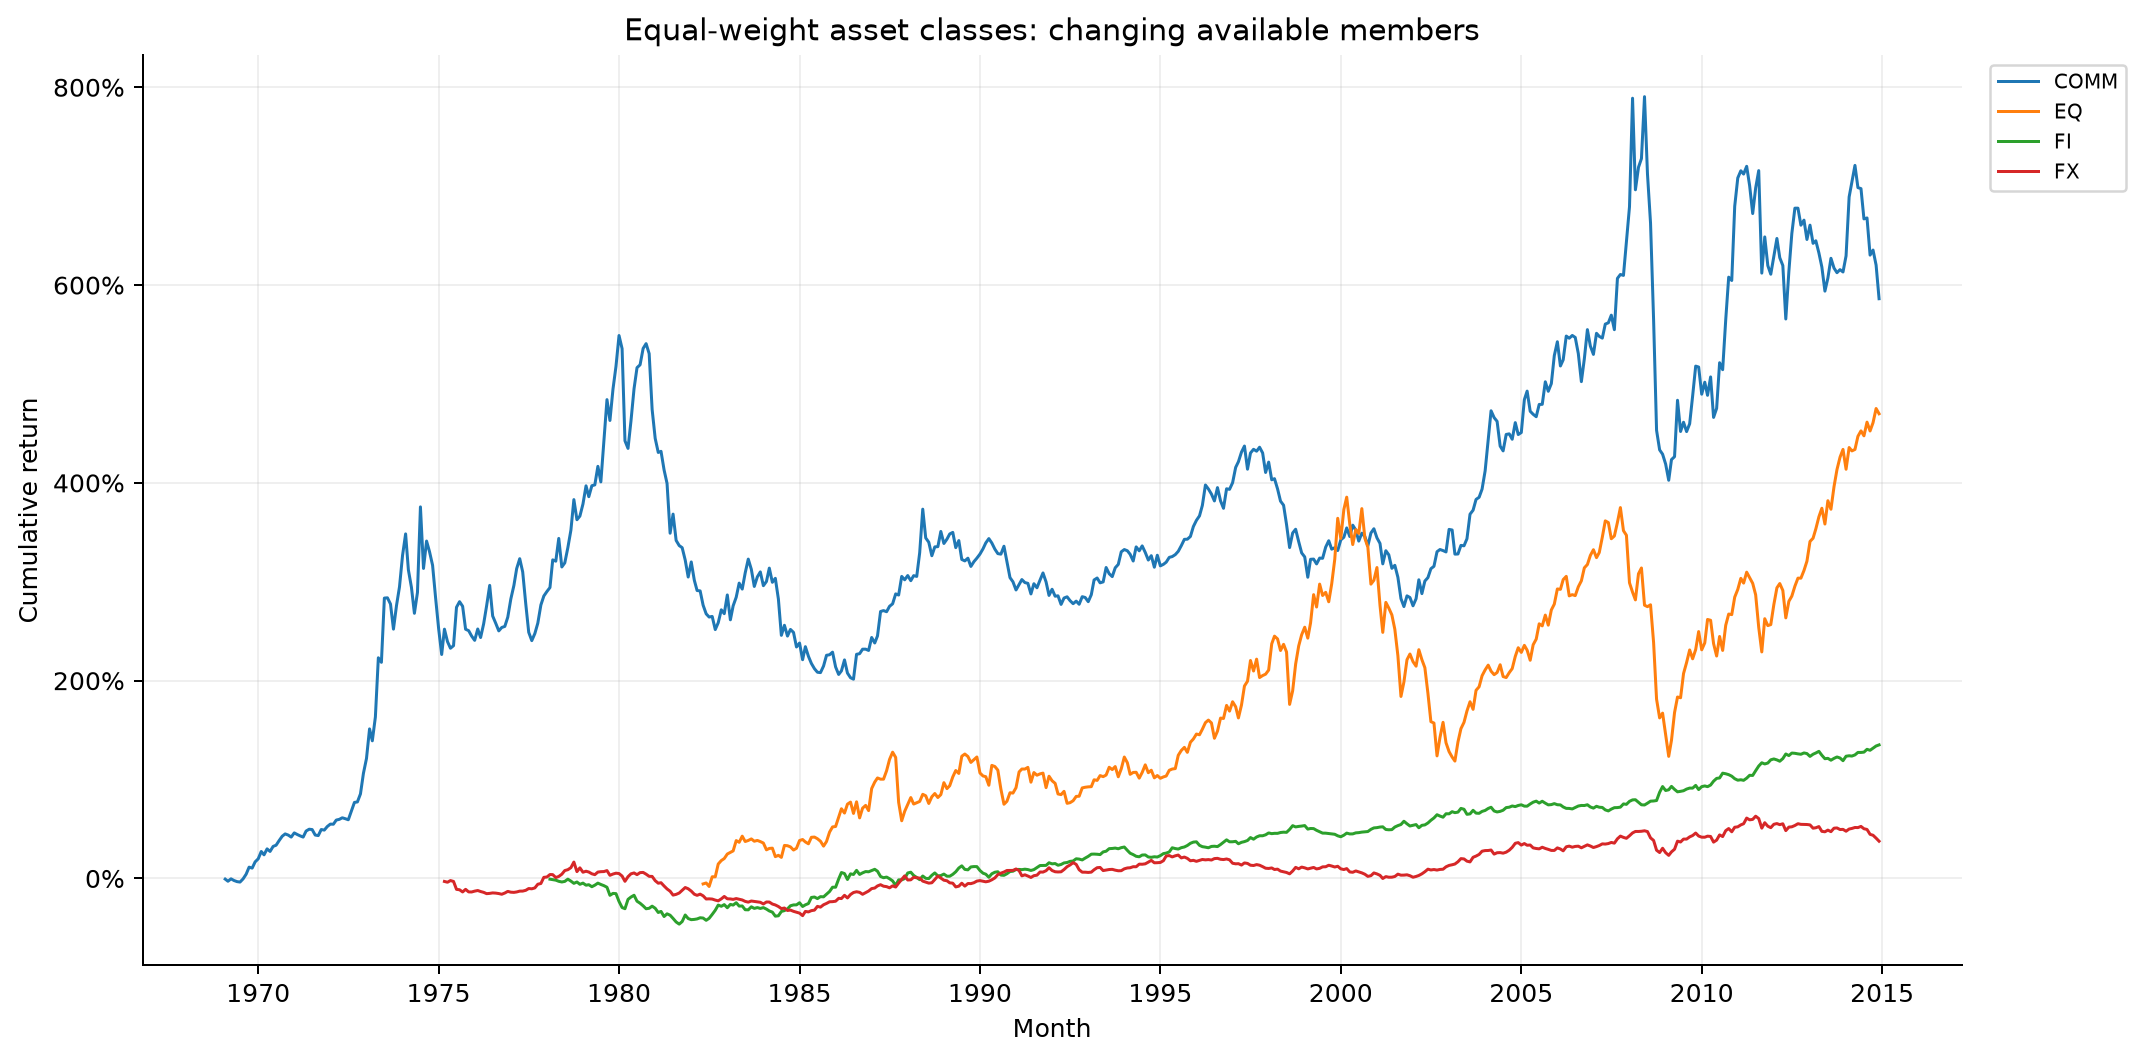

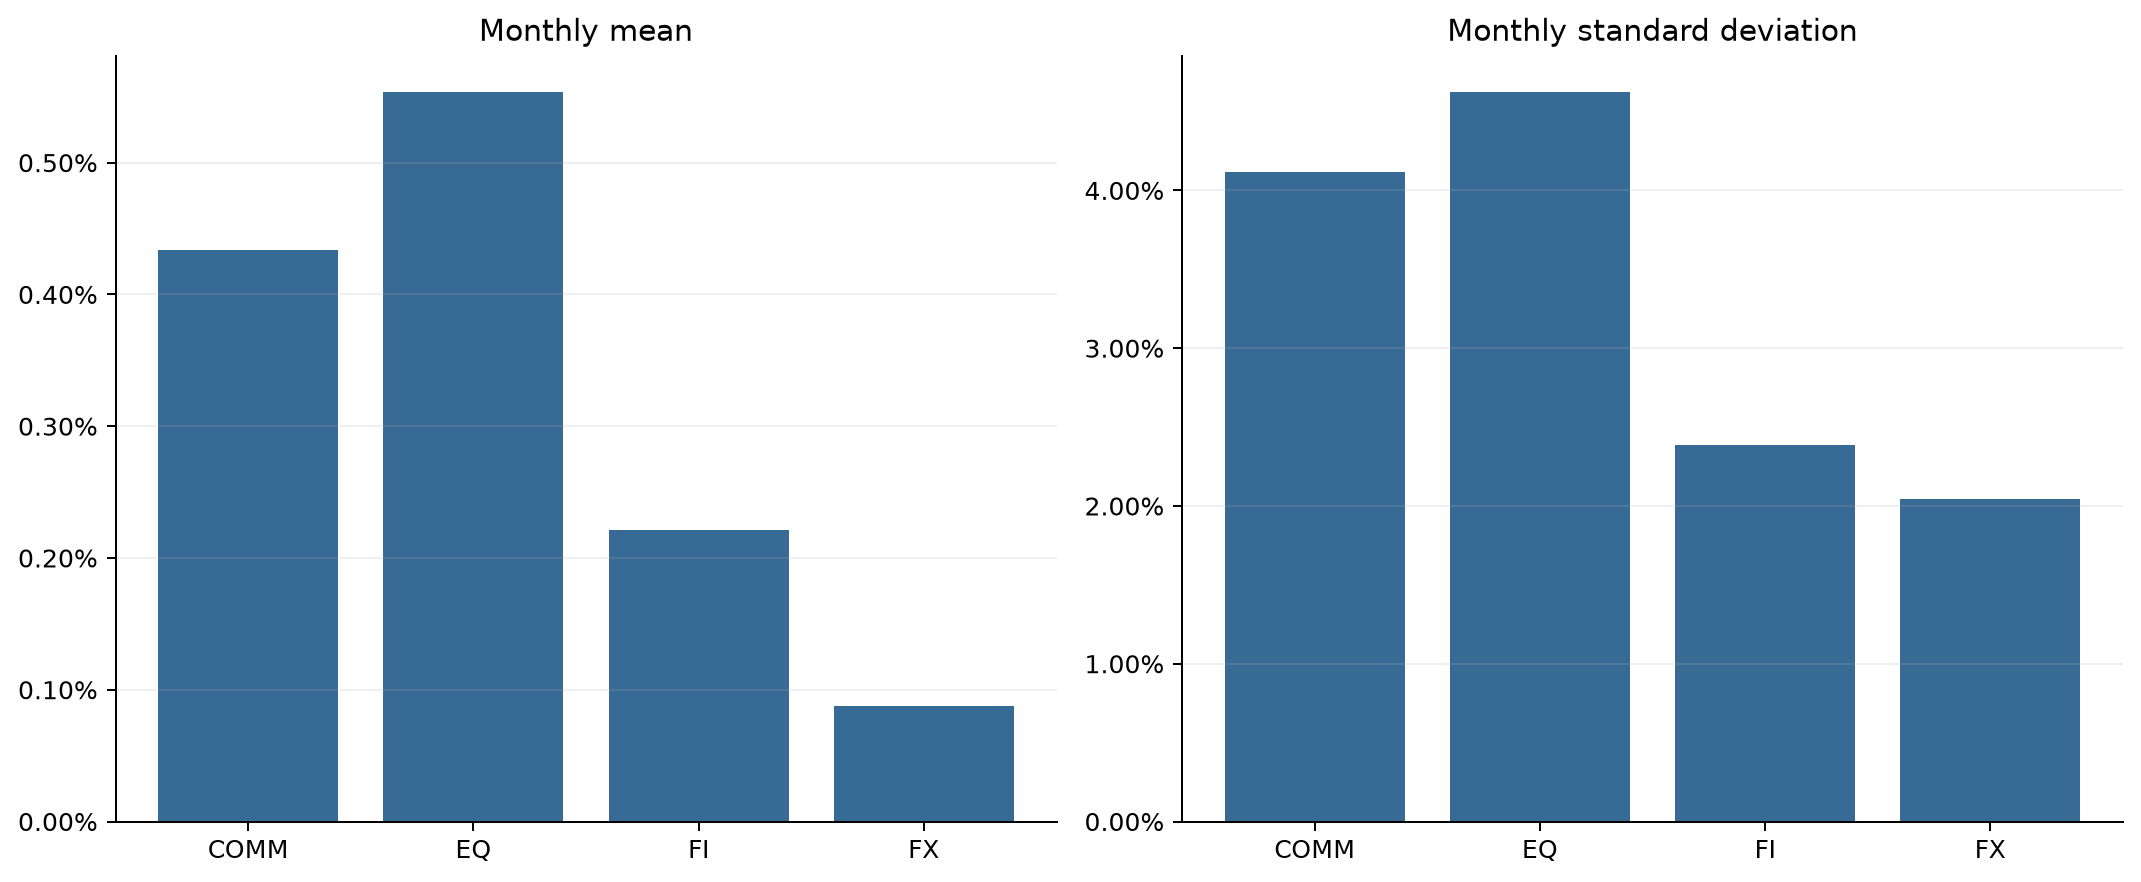

In [7]:
# Purpose: Export cumulative returns and charts by asset class and individual instrument.
def cumulative(frame):
    result = pd.DataFrame(np.nan, index=frame.index, columns=frame.columns)
    for symbol in frame:
        first = frame[symbol].first_valid_index()
        if first is not None:
            result.loc[first:, symbol] = (1+frame.loc[first:,symbol]).cumprod(skipna=False)-1
    return result
cum_instruments = cumulative(unique_returns)
cum_classes = cumulative(class_returns)
save_csv(cum_instruments, 'returns', 'cumulative_instrument_returns.csv')
save_csv(cum_classes, 'returns', 'cumulative_asset_class_returns.csv')
def line_chart(frame, title, ylabel, filename, percent=True, preview=False):
    fig, ax = plt.subplots(figsize=(12,6))
    for col in frame:
        ax.plot(frame.index.to_timestamp(), frame[col], label=col, linewidth=1.2)
    ax.set(title=title, xlabel='Month', ylabel=ylabel)
    if percent: ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(alpha=.2)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01,1), fontsize=8)
    save_figure(fig,filename,preview)
for category in sorted(asset_class.unique()):
    line_chart(cum_instruments.loc[:,asset_class == category], f'{category}: cumulative price returns (own histories)',
               'Cumulative return',f'cumulative_{category}')
for symbol in unique_returns:
    line_chart(cum_instruments[[symbol]],f'{symbol}: cumulative price return','Cumulative return',f'cumulative_instrument_{symbol}')
line_chart(cum_classes,'Equal-weight asset classes: changing available members','Cumulative return',
           'cumulative_asset_classes', preview=True)
line_chart(class_counts,'Number of available unique instruments','Instruments','asset_class_member_counts',False)
if len(common):
    group_id = pd.Series(common.index.asi8, index=common.index).diff().ne(1).cumsum()
    longest_id = group_id.value_counts().idxmax()
    contiguous = common.loc[group_id == longest_id]
    common_cum = cumulative(contiguous)
    save_csv(common_cum,'returns','cumulative_common_contiguous_sample.csv')
    common_class = pd.DataFrame({c:contiguous.loc[:,asset_class == c].mean(axis=1) for c in sorted(asset_class.unique())})
    line_chart(cumulative(common_class),'Asset classes: common continuous sample','Cumulative return','cumulative_common_classes')
    for category in sorted(asset_class.unique()):
        line_chart(common_cum.loc[:,asset_class == category],f'{category}: common continuous sample',
                   'Cumulative return',f'cumulative_common_{category}')
fig, axes = plt.subplots(1,2,figsize=(12,5))
for ax, column, title in zip(axes,['monthly_mean','monthly_std'],['Monthly mean','Monthly standard deviation']):
    ax.bar(class_stats.index,class_stats[column],color='#376a94')
    ax.set_title(title); ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.grid(axis='y',alpha=.2)
save_figure(fig,'class_mean_std',True)
fig, ax = plt.subplots(figsize=(11,6))
for category in sorted(asset_class.unique()):
    block=instrument_stats[instrument_stats.AssetClass == category]
    ax.scatter(block.monthly_std,block.monthly_mean,label=category,alpha=.75)
    for symbol,row in block.iterrows(): ax.annotate(symbol,(row.monthly_std,row.monthly_mean),fontsize=7)
ax.set(xlabel='Monthly standard deviation',ylabel='Monthly mean',title='Unique instruments: mean vs standard deviation')
ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.legend()
save_figure(fig,'instrument_mean_std')

## 8. Monthly Return Autocorrelation (Lags 1-24)
Purpose: calculate corr(r[t], r[t-k]) for instruments and asset classes, retaining the full monthly calendar before shifting.
Export all lags, selected lags 1/3/6/12, valid pair counts, and individual instrument/asset-class ACF charts.
Only pairs with both returns observed contribute to each correlation; missing months are not compressed out of the timeline.
The plotted +/-1.96/sqrt(N) bands are rough white-noise reference bounds, not multiple-testing-adjusted significance tests.
Here, horizon refers to the lag of monthly returns, not overlapping multi-month holding-period returns.

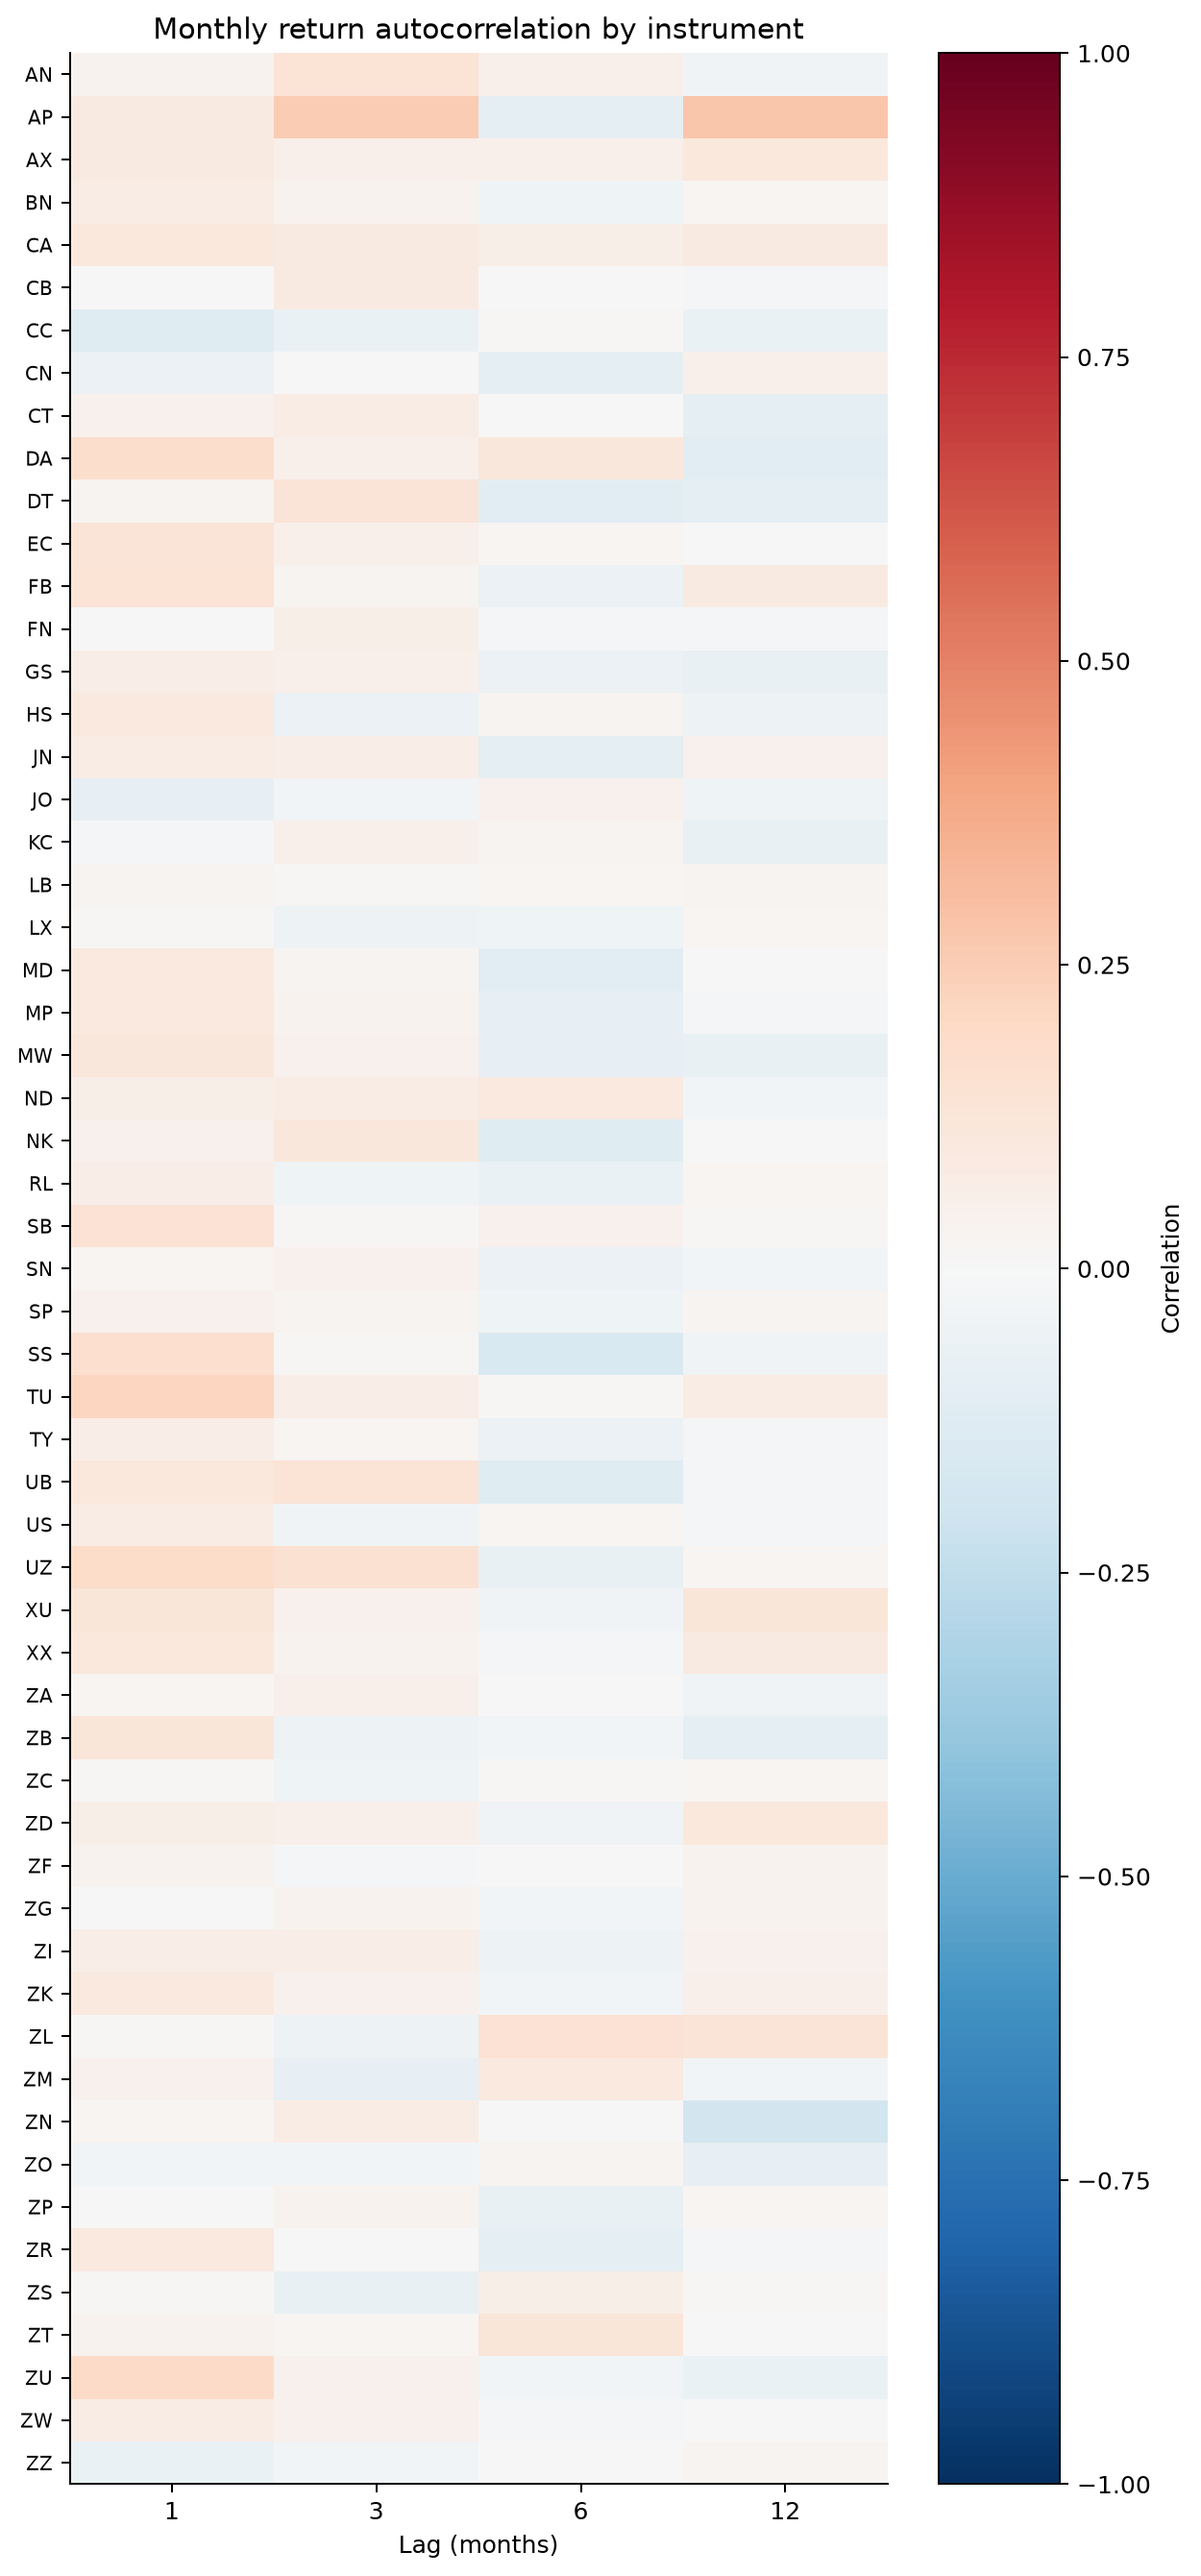

,level,ID,lag_months,autocorrelation,n_pairs,approx_95_bound
1368,asset_class,COMM,1,0.059382,550,0.083575
1370,asset_class,COMM,3,0.024591,548,0.083727
1373,asset_class,COMM,6,0.062890,545,0.083957
1379,asset_class,COMM,12,-0.006070,539,0.084423
1392,asset_class,EQ,1,0.071373,391,0.099121
1394,asset_class,EQ,3,-0.002398,389,0.099376
1397,asset_class,EQ,6,-0.029435,386,0.099761
1403,asset_class,EQ,12,-0.000168,380,0.100546
1416,asset_class,FI,1,0.107923,442,0.093228
1418,asset_class,FI,3,-0.112140,440,0.093439


In [8]:
# Purpose: Calculate autocorrelation using actual monthly lags and save the results.
acf_rows = []
for level, frame in [('instrument',unique_returns),('asset_class',class_returns)]:
    for symbol in frame:
        s=frame[symbol].reindex(calendar)
        for lag in range(1,PARAMS['acf_max_lag']+1):
            paired=pd.concat([s.rename('current'),s.shift(lag).rename('lagged')],axis=1).dropna()
            n=len(paired)
            corr=paired.current.corr(paired.lagged) if n>=3 and paired.current.std()>0 and paired.lagged.std()>0 else np.nan
            acf_rows.append({'level':level,'ID':symbol,'lag_months':lag,'autocorrelation':corr,
                            'n_pairs':n,'approx_95_bound':1.96/np.sqrt(n) if n else np.nan})
acf=pd.DataFrame(acf_rows)
save_csv(acf,'statistics','autocorrelation_all_lags.csv',False)
save_csv(acf[acf.lag_months.isin(PARAMS['acf_lags'])],'statistics','autocorrelation_selected_lags.csv',False)
for (level,symbol),block in acf.groupby(['level','ID']):
    fig,ax=plt.subplots(figsize=(9,4))
    ax.bar(block.lag_months,block.autocorrelation,color='#376a94')
    ax.plot(block.lag_months,block.approx_95_bound,'--',color='#b44842',label='Approx. white-noise bounds')
    ax.plot(block.lag_months,-block.approx_95_bound,'--',color='#b44842')
    ax.axhline(0,color='black',linewidth=.7)
    ax.set(title=f'{symbol}: monthly return autocorrelation',xlabel='Lag (months)',ylabel='Correlation',xticks=[1,3,6,12,18,24])
    ax.legend(fontsize=8)
    save_figure(fig,f'acf_{level}_{symbol}')
heat=acf[(acf.level=='instrument') & acf.lag_months.isin(PARAMS['acf_lags'])].pivot(index='ID',columns='lag_months',values='autocorrelation')
fig,ax=plt.subplots(figsize=(7,15))
im=ax.imshow(heat.values,aspect='auto',cmap='RdBu_r',vmin=-1,vmax=1)
ax.set_xticks(range(len(heat.columns)),heat.columns); ax.set_yticks(range(len(heat.index)),heat.index,fontsize=8)
ax.set(title='Monthly return autocorrelation by instrument',xlabel='Lag (months)')
fig.colorbar(im,ax=ax,label='Correlation')
save_figure(fig,'acf_instrument_heatmap',True)
display(acf[(acf.level=='asset_class') & acf.lag_months.isin(PARAMS['acf_lags'])])

## 9. Prepare the Supplementary Workbook
Purpose: read Lecture3_livedata.xlsx, check month uniqueness, coverage, missing values, and column names,
and export the data to a monthly CSV file.
Keep these observations as supplementary inputs for possible factor analysis.
Do not automatically combine long-short factor returns with ordinary asset returns.
This step does not perform additional regression analysis outside the requested scope.

In [9]:
# Purpose: Read and check the supplementary workbook without modifying its source.
lecture=pd.read_excel(DATA/'Lecture3_livedata.xlsx',sheet_name=0,engine='openpyxl')
lecture['Date']=pd.to_datetime(lecture['Date'])
lecture['Month']=lecture.Date.dt.to_period('M')
assert not lecture.Month.duplicated().any(), 'Duplicate months in the supplementary data.'
save_csv(lecture,'cleaned','lecture3_monthly_factors.csv',False)
lecture_summary=pd.DataFrame({'column':lecture.columns,'missing':lecture.isna().sum().values})
save_csv(lecture_summary,'quality','lecture3_column_summary.csv',False)
print('Supplementary data:',lecture.Month.min(), 'to',lecture.Month.max(), 'count:',len(lecture),'months')

Supplementary data: 2000-01 to 2014-12 count: 180 months


## 10. Validation, Results Report, and Output Inventory
Purpose: verify return-source selection, reconciliation of jointly observed values, return coverage,
equal-weight portfolio weights, autocorrelation pair counts, and unchanged source files.
Write the English results report, environment information, and a complete output inventory.
Retain missingness differences and data-quality flags explicitly.
These checks verify implementation consistency; they do not establish that every raw observation is correct.

In [10]:
# Purpose: Validate key calculation relationships and compile the output inventory.
assert len(raw)==62 and recreated.shape[1]==58 and unique_returns.shape[1]==57
assert recreated.index.is_unique and recreated.index.is_monotonic_increasing
assert not np.isinf(unique_returns.to_numpy()).any()
assert np.allclose(recreated.loc[calendar>=switch,'RL'],raw_monthly_returns.loc[calendar>=switch,'ER'],equal_nan=True)
assert not (reconciliation.status=='value_mismatch').any(), 'Jointly observed returns differ; review the reconciliation differences.'
weights_all=pd.concat(weight_frames,ignore_index=True)
weight_sums=weights_all.groupby(['Month','AssetClass']).weight.sum()
assert np.allclose(weight_sums,1.0)
for k in PARAMS['acf_lags']:
    s=unique_returns.iloc[:,0]
    expected=int((s.notna() & s.shift(k).notna()).sum())
    actual=acf[(acf.level=='instrument') & (acf.ID==s.name) & (acf.lag_months==k)].n_pairs.iloc[0]
    assert expected==actual
for row in source_inventory.itertuples():
    assert hashlib.sha256((ROOT/row.file).read_bytes()).hexdigest()==row.sha256, 'A source file has changed.'
environment={'python':platform.python_version(),'pandas':pd.__version__,'numpy':np.__version__,
             'matplotlib':matplotlib.__version__}
(OUT/'environment.json').write_text(json.dumps(environment,indent=2),encoding='utf-8')
counts=reconciliation.status.value_counts().to_dict()
report=f"""# Futures Data Analysis Results

## Data and Validation
- Raw instruments: {len(raw)}; reference reconstruction: {recreated.shape[1]}; unique economic instruments: {unique_returns.shape[1]}.
- Monthly calendar: {calendar.min()} to {calendar.max()}.
- Quality events (including calendar-gap flags): {len(quality_events)}; flagged daily returns: {len(daily_flags)}; flagged monthly returns: {len(monthly_flags)}.
- Reconciliation status: {counts}. Numeric tolerance: {PARAMS['reconciliation_tolerance']}.
- All input SHA-256 checks passed; source files remain unchanged.

## Methodology
- Returns are adjacent month-end Close ratios minus one. Missing prices are not forward-filled; dates are aligned by calendar month.
- Starting in {switch}, RL uses ER's own monthly returns. Price levels are not spliced directly.
- The primary exports MonthlyReturns.csv and data/MonthlyReturns_cleaned.csv retain all 58 reference columns, including both ZD and YM. The two files are byte-identical.
- The optional 57-column analysis excludes YM and retains ZD for Dow Jones. This is an additional modeling choice, not a requirement of the screenshot. SP and ND represent their respective ordinary/mini candidate groups.
- The primary exports preserve the reference date labels and column order, retaining 32 reconstructable reference-missing values without statistical imputation. The original data/MonthlyReturns.csv remains unchanged.
- Asset classes equally weight instruments with observed returns each month and rebalance monthly. Actual weights are saved in returns/asset_class_weights.csv.
- Quoted currencies are not converted to USD. Continuous-contract adjustment and roll methods require clarification from the course data provider.
- Full-history samples differ across instruments; the common observed sample contains {len(common)} months.
- Cumulative returns stop at the first internal missing return; unknown returns are not set to zero.
- Autocorrelation uses monthly-return lags 1-24. Reference bands are not formal significance conclusions.

## Items Requiring Review
- AssetMap entries BC, BG, FF, and ZH have no corresponding raw files.
- Raw OHLC anomalies and large returns are retained; see quality/.
- reference_missing indicates a missing reference value that can be reconstructed from raw prices; rebuilt_missing indicates the reverse. See the reconciliation differences.
- Statistics are preliminary pending manual outlier review. Genuine extreme market moves are not removed automatically.

## Output Guide
- quality/: input inventory, coverage checks, and anomaly records.
- cleaned/: standardized daily observations, asset mapping, selection rules, and supplementary factor data.
- returns/: month-end prices, 62/58/57-instrument returns, class returns, weights, cumulative returns, and full reconciliation.
- statistics/: instrument and class summaries, common-sample statistics, and ACF results.
- figures/: all PNG and SVG charts.
"""
(OUT/'report.md').write_text(report,encoding='utf-8')
files=[{'file':str(p.relative_to(OUT)),'bytes':p.stat().st_size} for p in sorted(OUT.rglob('*')) if p.is_file() and p.name!='manifest.csv']
pd.DataFrame(files).to_csv(OUT/'manifest.csv',index=False,encoding='utf-8-sig')
print('Key checks passed. Output files (including manifest):',len(files)+1)
print('PNG charts:',len(list(DIR['figures'].glob('*.png'))))
print('Report:',OUT/'report.md')

Key checks passed. Output files (including manifest): 301
PNG charts: 132
Report: C:\Users\miaoy\Desktop\ORIE 5260\output\report.md
